# **Box Office Collection Prediction Model**

After Cleaning and Visualizing the data, Now we are going to Create a Model to Predict Box Office Range Using Superverised Machine Learning Algorithm

## **Libraries**

In [83]:
import sklearn as sk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data

In [84]:
model=pd.read_excel('Final Cleaned Dataset.xlsx')
print(model.columns)

Index(['Movie Title', 'Release Year', 'Genres', 'IMDb Rating', 'Director',
       'Actor 1', 'Actor 2', 'User Votes', 'Box Office Collections'],
      dtype='object')


In [85]:
print(model['Box Office Collections'].head())

0     28341469.0
1    134966411.0
2    534858444.0
3     57300000.0
4      4360000.0
Name: Box Office Collections, dtype: float64


In [86]:
# Use qcut to create 3 equal-sized bins (quantiles)
model['Collection Range'], bins = pd.qcut(model['Box Office Collections'], q=3, labels=['Flop', 'Mediocre', 'Hit'], retbins=True)

# Check distribution
print(model['Collection Range'].value_counts())
print("Bin edges:", bins)

Collection Range
Hit         334
Flop        333
Mediocre    333
Name: count, dtype: int64
Bin edges: [1.30500000e+03 1.12861120e+07 4.23405980e+07 9.36662225e+08]


In [87]:
# Drop non-predictive columns
model = model.drop(columns=['Movie Title', 'Box Office Collections'])

# Define features and target
features = ['Release Year', 'Genres', 'IMDb Rating', 'Director', 
            'Actor 1', 'Actor 2', 'User Votes']
target = 'Collection Range'

X = model[features]
y = model[target]

# Quick check
print("Features:\n", X.head())
print("\nTarget:\n", y.head())


Features:
    Release Year                Genres  IMDb Rating              Director  \
0          1994                 Drama          9.3        Frank Darabont   
1          1972          Crime, Drama          9.2  Francis Ford Coppola   
2          2008  Action, Crime, Drama          9.0     Christopher Nolan   
3          1974          Crime, Drama          9.0  Francis Ford Coppola   
4          1957          Crime, Drama          9.0          Sidney Lumet   

          Actor 1         Actor 2  User Votes  
0     Tim Robbins  Morgan Freeman     2343110  
1   Marlon Brando       Al Pacino     1620367  
2  Christian Bale    Heath Ledger     2303232  
3       Al Pacino  Robert De Niro     1129952  
4     Henry Fonda     Lee J. Cobb      689845  

Target:
 0    Mediocre
1         Hit
2         Hit
3         Hit
4        Flop
Name: Collection Range, dtype: category
Categories (3, object): ['Flop' < 'Mediocre' < 'Hit']


In [88]:
from sklearn.preprocessing import LabelEncoder

# Columns that need encoding
label_cols = ['Genres', 'Director', 'Actor 1', 'Actor 2']

# Dictionary to store encoders (useful if you want to decode later)
le_dict = {}

# Apply Label Encoding
for col in label_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le  # Save the encoder for future use
# Check the transformed features
print(X[label_cols].head())

   Genres  Director  Actor 1  Actor 2
0     136       141      599      566
1     121       137      417        9
2      22        83      128      282
3     121       137        9      655
4     121       455      252      463


C:\Users\Dell\AppData\Local\Temp\ipykernel_16344\2357033491.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\Dell\AppData\Local\Temp\ipykernel_16344\2357033491.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\Dell\AppData\Local\Temp\ipykernel_16344\2357033491.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

## **Splitting Dataset**

In [89]:
from sklearn.model_selection import train_test_split

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Quick check of shapes
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Testing target distribution:\n{y_test.value_counts(normalize=True)}")


Training data shape: (800, 7)
Testing data shape: (200, 7)
Training target distribution:
Collection Range
Mediocre    0.33375
Hit         0.33375
Flop        0.33250
Name: proportion, dtype: float64
Testing target distribution:
Collection Range
Flop        0.335
Hit         0.335
Mediocre    0.330
Name: proportion, dtype: float64


## **Model Building**

Classification Report:
               precision    recall  f1-score   support

        Flop       0.58      0.58      0.58        67
         Hit       0.71      0.73      0.72        67
    Mediocre       0.50      0.48      0.49        66

    accuracy                           0.60       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.60      0.60      0.60       200

Confusion Matrix:
 [[39  6 22]
 [ 8 49 10]
 [20 14 32]]


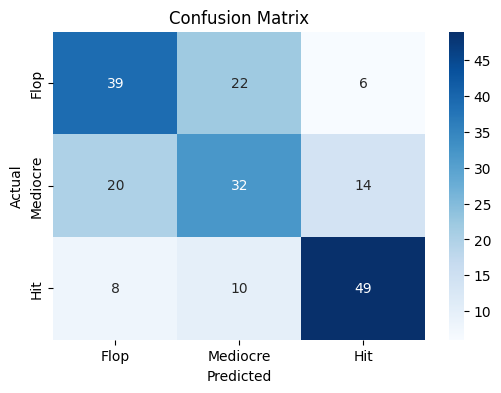

In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize model
Model = RandomForestClassifier(n_estimators=200, random_state=42)

# Train model
Model.fit(X_train, y_train)

# Predict on test set
y_pred = Model.predict(X_test)

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['Flop', 'Mediocre', 'Hit'])

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Flop', 'Mediocre', 'Hit'],
            yticklabels=['Flop', 'Mediocre', 'Hit'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### **🔍 Interpretation:**
Diagonal values (40, 29, 18, 23) represent correct predictions.

For Flop, 40 correctly predicted, but 8 wrongly predicted as Hit — so some misclassification with middle categories.

For Mediocre, 29 correct, but 10 misclassified as Blockbuster (too optimistic predictions).

For Hit and Blockbuster, more confusion with neighboring classes — e.g., Hit predicted as Flop or Blockbuster, Blockbuster misclassified often as Hit or Mediocre.

### **What does this mean?**
The model is decent but confuses movies near category boundaries — like distinguishing between Hit and Blockbuster or Mediocre and Blockbuster.

It tends to misclassify some middle-range movies into adjacent classes.

## **Hyper Parameter Tuning**

In [91]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearch with Random Forest
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearch on training data
grid_search.fit(X_train, y_train)

# Best parameters found
print("Best Parameters:", grid_search.best_params_)

# Best estimator
best_model = grid_search.best_estimator_

# Predict & Evaluate on test set
y_pred_best = best_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

        Flop       0.59      0.61      0.60        67
         Hit       0.72      0.73      0.73        67
    Mediocre       0.52      0.50      0.51        66

    accuracy                           0.61       200
   macro avg       0.61      0.61      0.61       200
weighted avg       0.61      0.61      0.61       200



In [92]:
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

# Label encode target classes
le = LabelEncoder()
le.fit(y_train)  # fit on training target labels

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

# List of categorical columns
categorical_cols = ['Genres', 'Director', 'Actor 1', 'Actor 2']
num_features = ['Release Year', 'IMDb Rating', 'User Votes']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', num_features)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

# XGBoost model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Complete pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb)
])

# Hyperparameter grid
param_dist = {
    'classifier__max_depth': [6, 10, 15, 20],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__n_estimators': [50, 100, 150],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

# RandomizedSearchCV setup
search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist,
    n_iter=20, cv=5, verbose=2, n_jobs=-1, random_state=42
)

# Fit model on encoded training data
search.fit(X_train, y_train_enc)

print("Best Parameters:", search.best_params_)
print("Best CV Score:", search.best_score_)

# Predict on test data
y_pred = search.predict(X_test)

# Print classification report with original class names
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))


Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:43:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'classifier__subsample': 0.6, 'classifier__n_estimators': 50, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}
Best CV Score: 0.65875
              precision    recall  f1-score   support

        Flop       0.57      0.61      0.59        67
         Hit       0.71      0.72      0.71        67
    Mediocre       0.53      0.48      0.51        66

    accuracy                           0.60       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.60      0.60      0.60       200



In [93]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

# Encode target labels if not already done
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Categorical columns
categorical_cols = ['Genres', 'Director', 'Actor 1', 'Actor 2']
numerical_cols = ['User Votes', 'Release Year', 'IMDb Rating']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Create pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(max_depth=10, learning_rate=0.01, n_estimators=50, num_leaves=15))
])


# Hyperparameter search space
param_grid = {
    'classifier__num_leaves': [15, 31, 50],
    'classifier__max_depth': [5, 10, 15],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__n_estimators': [50, 100, 150],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
}

# Randomized Search for hyperparameter tuning
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
pipeline.fit(X_train, y_train_enc)
search.fit(X_train, y_train_enc)

# Predictions
y_pred = search.predict(X_test)

# Output results
print("Best Parameters:", search.best_params_)
print("Best CV Score:", search.best_score_)
print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 369
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 11
[LightGBM] [Info] Start training from score -1.101115
[LightGBM] [Info] Start training from score -1.097363
[LightGBM] [Info] Start training from score -1.097363
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 369
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 11
[LightGBM] [Info] Start training from score -1.101115
[LightGBM] [Info] Start training from score -1.097363
[LightGBM] [Info] Start training

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


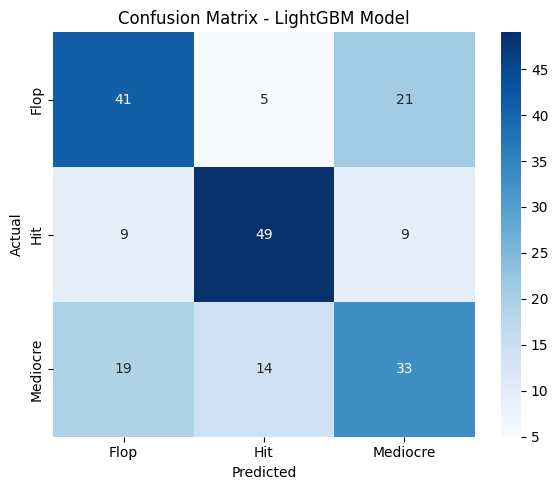

In [94]:
# Predict on test set
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=le.classes_)

# Plot as Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LightGBM Model")
plt.tight_layout()
plt.show()

In [95]:
print(type(best_model))
lgbm_model = best_model

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


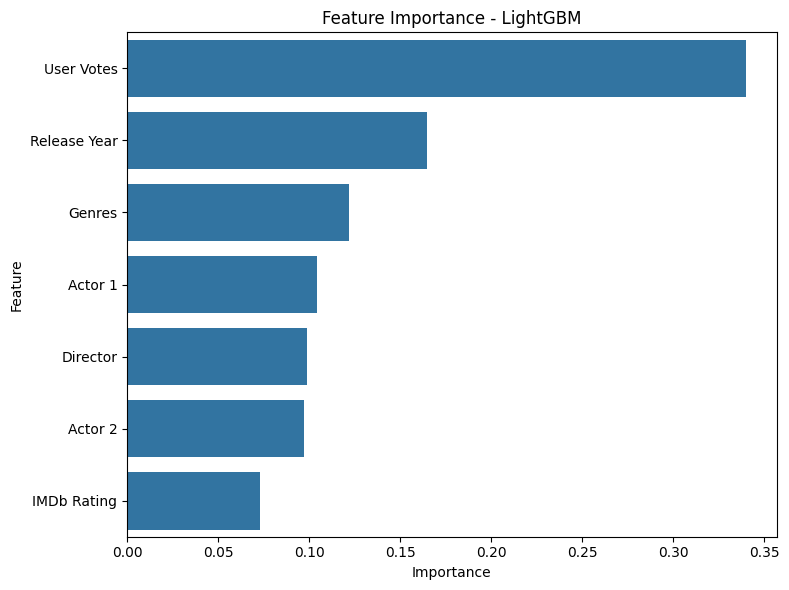

In [96]:
# Extract the classifier from pipeline
lgbm_model = best_model

# Get feature names
feature_names = X_train.columns

# Get importances
importances = lgbm_model.feature_importances_

# Create a DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title("Feature Importance - LightGBM")
plt.tight_layout()
plt.show()


In [97]:
import joblib

# Assuming your best model after GridSearchCV is in grid_search.best_estimator_
best_model = grid_search.best_estimator_

# Save the model to a file
joblib.dump(pipeline, 'box_office_model_pipeline.pkl')


['box_office_model_pipeline.pkl']

In [103]:
# Load saved pipeline model
model = joblib.load('box_office_model_pipeline.pkl')
joblib.dump(le, "label_encoder.pkl")  # Save during training
# Then in inference
le = joblib.load("label_encoder.pkl")
print("Predicted Category:", le.inverse_transform(prediction)[0])

# Create one new movie sample as DataFrame (same feature columns as training)
new_movie = pd.DataFrame({
    'Release Year': [2024],
    'Genres': ['Sci-fi|Drama'],   # same format as your data
    'IMDb Rating': [4.7],
    'Director': ['Francis Ford Coppola'],
    'Actor 1': ['Adam Driver'],
    'Actor 2': ['Aubrey Plaza'],
    'User Votes': [36000]
})

# Predict class for this new movie
prediction = pipeline.predict(new_movie)

print("Predicted Box Office Category:", prediction[0])


Predicted Category: Mediocre
Predicted Box Office Category: 2


c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
